In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

# global_path = "/home/ids/edabier/HSU"
global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

False
Using device: cpu


In [37]:
dataset = "samson"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [16]:
unmixer = rsfm.Unmixing_from_features3(H=H, B=B, c=c)
sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6

0.001592

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
SAD = 0.152 ± 0.05, NMSE = 0.565 ± 0.25


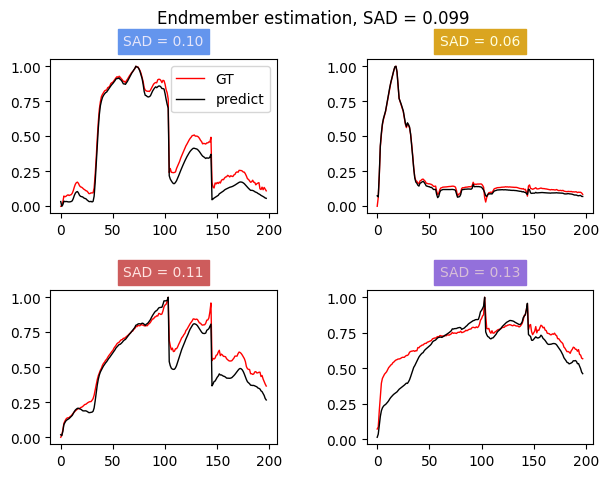

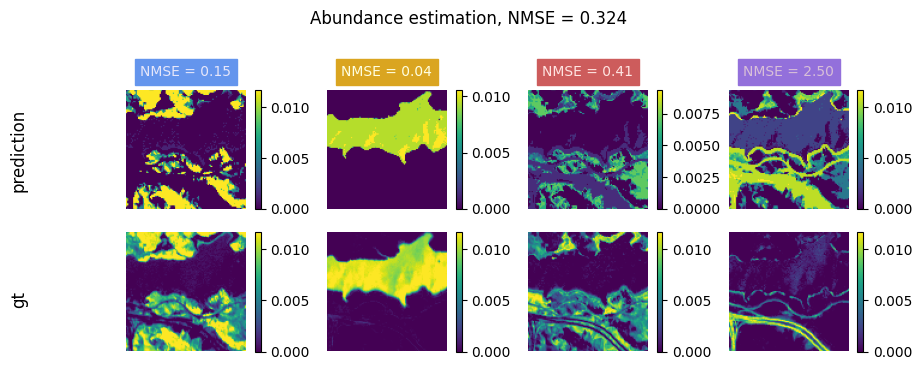

In [ ]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 10
mses, sads = [], []
mses_in, sads_in = [], []

E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H, H)
torch.autograd.set_detect_anomaly(True)

for n in range(n_xp):

    model = rsfm.Unmixing_from_features3(H=H, B=B, c=c)
    # model = torch.compile(model)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init, c, is_unmixer=True, normalize=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)
    # scaler = torch.amp.GradScaler("cuda")

    flag = False

    for epoch in range(epochs):
        
        for Y, E, A in loader:
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev, dtype=torch.float)
            Y = Y/Y.max()

            # with torch.amp.autocast("cuda"):
            E_hat, A_hat, Y_hat = model(Y)
            loss, loss1, loss2, loss3, loss4 = model.loss(Y, Y_hat, A_hat, E_hat)

            if E_hat.isnan().any():
                print(loss1, loss2, loss3, loss4)
                flag = True
                break
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            # scaler.scale(loss).backward()
            # scaler.step(optimizer)
            # scaler.update()

            if hasattr(model, 'decoder'):
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
        
    model.eval()

    if not flag:
        with torch.no_grad():
            E_hat, A_hat, _ = model(Y_init)
            sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
            sads.append(sad)
            mses.append(mse)

    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)

sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)
# sads.append(sad)
# mses.append(mse)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")
# feat_up = model.upsample(features)
# feat_up = feat_up.reshape(D, new_H, new_H)
# plots.plot_hsi(feat_up, 4)